<div style="background:#4a1c26;color:#f7efe9;padding:26px 30px;border-radius:6px;margin-bottom:18px">
  <h1 style="margin:0 0 10px;color:#fff">Winery Adventures</h1>
  <p style="margin:0;font-size:1.15em">Dalle rilevazioni dei sensori allo stress di fermentazione: una pipeline Polars + Numba da interrogare cella per cella.</p>
</div>

| Scheda del progetto | |
|---|---|
| **Autori** | Alexandro Sanna · Jacopo Bertucelli |
| **Corso** | Ingegneria del Software, progetto bonus, A.A. 2025/2026 — Informatica Applicata e Data Analytics (IADA), Università degli Studi di Cagliari |
| **Repository** | [JacopoBertucelli/Winery-Adventures---Bertucelli-Sanna](https://github.com/JacopoBertucelli/Winery-Adventures---Bertucelli-Sanna) |
| **Strumenti** | Python ≥ 3.10 · Polars · Numba · Joblib · Weights & Biases · uv · Ruff · Pytest · GitHub Actions |

**In breve.** Una cantina ha delle cisterne di fermentazione con sensori che registrano pH, temperatura e quantità di mosto. Il programma legge quelle letture, calcola per ogni cisterna alcuni indicatori — tra cui lo *stress di fermentazione* richiesto dalla traccia — e produce un file CSV e una dashboard che segnala le cisterne da tenere d'occhio. È stato usato: Polars per le tabelle, Numba per il calcolo pesante, Joblib per lavorare in parallelo e, facoltativo, Weights & Biases per registrare i risultati.

**Questo notebook** segue l'ordine della presentazione. Le tabelle, le misure e i grafici numerici vengono ricalcolati dalle celle del notebook; le immagini servono come supporto visivo alla spiegazione. La cisterna 9 — la più piccola e la più "stressata" — ci accompagna dall'inizio alla fine.

| Sezione | Cosa mostriamo |
|---|---|
| [Apertura e organizzazione del lavoro](#parte1) | cos'è il progetto; repository, board Kanban, branch e pull request |
| [Qualità automatica](#parte2) | i 22 test e l'integrazione continua che li esegue a ogni modifica |
| [Il sistema](#parte3) | architettura e UML, dati in ingresso, la pipeline al lavoro, formula di stress, W&B |
| [Prestazioni e dashboard](#parte4) | Python contro Numba, andamento O(n²), Joblib e report; la dashboard |
| [Limiti e conclusione](#parte5) | cosa il sistema non fa e cosa ci portiamo a casa |


In [ ]:
# ▶ ambiente: radice del repository, cartella di lavoro, W&B offline,
# logging della pipeline e stile dei grafici.
import logging
import os
import subprocess
import sys
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numba
import numpy as np
import polars as pl
from IPython.display import HTML, Markdown, display

repo_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
demo_dir = repo_root / "output" / "demo"  # cartella ignorata da Git
demo_dir.mkdir(parents=True, exist_ok=True)
os.environ.update(WANDB_MODE="offline", WANDB_SILENT="true", WANDB_DIR=str(demo_dir))
logging.basicConfig(
    level=logging.INFO, format="%(levelname)s %(name)s: %(message)s", stream=sys.stdout
)
pl.Config.set_tbl_cols(12)
pl.Config.set_float_precision(3)

BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#d03b3b"  # due serie, anomalie
INK, MUTED, GRID = "#52514e", "#898781", "#e1e0d9"  # testo, assi, griglia
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})


def sh(*args: str) -> str:
    """Esegue un comando nella radice del repository e ne restituisce l'output."""
    return subprocess.run(args, capture_output=True, text=True, cwd=repo_root).stdout


def style_axes(ax: plt.Axes) -> None:
    """Griglia leggera, cornice solo in basso e a sinistra, testo grigio scuro."""
    ax.grid(color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=INK, labelsize=9)


versions = [sys.version.split()[0], pl.__version__, numba.__version__]
branch = sh("git", "branch", "--show-current").strip()
ambiente = {
    "Python / Polars / Numba": " / ".join(versions),
    "NumPy / Joblib": f"{np.__version__} / {joblib.__version__}",
    "Branch · commit": f"`{branch}` · "
    + sh("git", "log", "-1", "--format=`%h` %s").strip(),
    "W&B": os.environ["WANDB_MODE"],
}
righe = "\n".join(f"| {nome} | {valore} |" for nome, valore in ambiente.items())
display(Markdown(f"| Ambiente della demo | |\n|---|---|\n{righe}"))

| Ambiente della demo | |
|---|---|
| Python / Polars / Numba | 3.14.6 / 1.42.1 / 0.66.0 |
| NumPy / Joblib | 2.4.6 / 1.5.3 |
| Branch · commit | `main` · `6929bfb` Merge pull request #9 from JacopoBertucelli/chore/memoria-docstring |
| W&B | offline |

<a id="parte1"></a>
<div style="background:#f3e9e4;color:#2b2523;border-left:6px solid #7b2d3b;padding:12px 18px;margin:30px 0 14px;border-radius:0 6px 6px 0">
  <div style="font-size:1.3em;font-weight:600;margin:0 0 6px">Apertura e organizzazione del lavoro</div>
  <ul style="margin:0;padding-left:20px;font-size:.92em"><li>Cosa fa il progetto, in una figura: dai file dei sensori al CSV e alla dashboard.</li><li>Come è nato il repository e come abbiamo lavorato in due: board Kanban, branch, pull request.</li><li>Chi ha fatto cosa.</li></ul>
</div>

<figure style="margin:20px 0;text-align:center">
  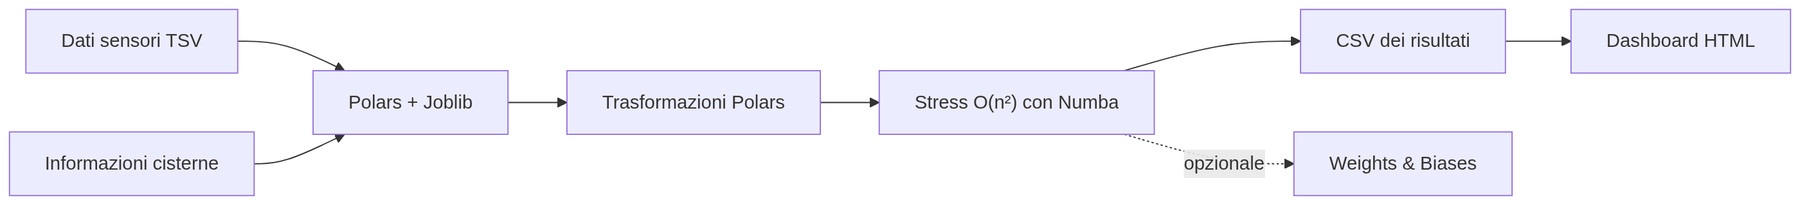
  <figcaption style="font-size:.88em;font-style:italic;margin-top:8px">Figura 1 — Il flusso del sistema, dal README del progetto: i dati dei sensori e le informazioni sulle cisterne entrano, il CSV dei risultati e la dashboard escono; Weights & Biases è opzionale.</figcaption>
</figure>

Il lavoro è stato diviso per aree: Jacopo la pipeline, i diagrammi UML, il README e le rifiniture finali; Alexandro i test, l'integrazione continua, il benchmark e la dashboard. Le attività sono state organizzate su una board Kanban in **Jira**.

<figure style="margin:20px 0;text-align:center">
  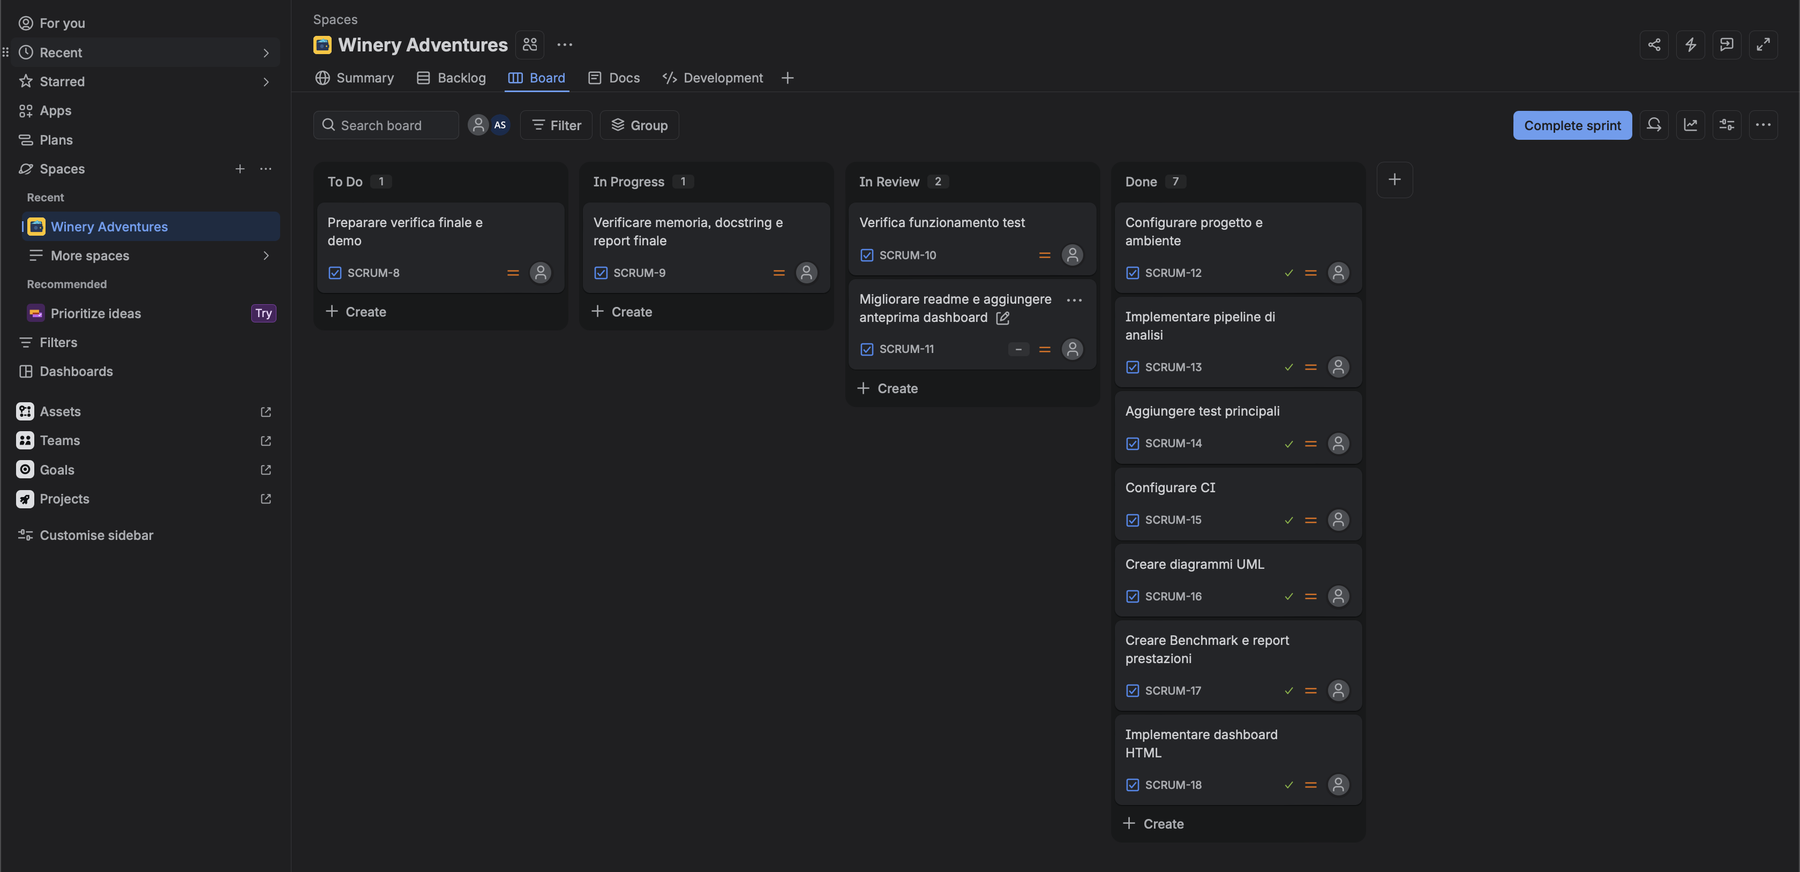
  <figcaption style="font-size:.88em;font-style:italic;margin-top:8px">Figura 2 — La board Kanban del progetto su Jira: le attività nelle colonne To Do, In Progress, In Review e Done.</figcaption>
</figure>

### Branch e pull request

Per le attività principali abbiamo usato branch tematici e pull request, così da separare implementazione, controllo e integrazione; la cronologia di `main` racconta il progetto passo per passo. La CI esegue Ruff e Pytest su push e pull request verso `main`: è l'argomento della sezione successiva.

| PR | Data | Contenuto | Autore |
|---|---|---|---|
| #1 | 3 set | pipeline di analisi e dati di esempio | Jacopo |
| #2 | 5 set | primi test automatici | Alexandro |
| #3 | 5 set | integrazione continua con Ruff e Pytest | Alexandro |
| #4 | 5 set | i tre diagrammi UML | Jacopo |
| #5 | 6 set | generatore di dati, benchmark e report delle prestazioni | Alexandro |
| #6 | 6 set | dashboard HTML | Alexandro |
| #7 | 14 set | suite di test del tutor ripristinata e allineata | Alexandro |
| #8 | 14 set | README esteso e grafico di sintesi | Jacopo |
| #9 | 15 set | misura della memoria nel benchmark e docstring | Jacopo |

<a id="parte2"></a>
<div style="background:#f3e9e4;color:#2b2523;border-left:6px solid #7b2d3b;padding:12px 18px;margin:30px 0 14px;border-radius:0 6px 6px 0">
  <div style="font-size:1.3em;font-weight:600;margin:0 0 6px">Qualità automatica: test e integrazione continua</div>
  <ul style="margin:0;padding-left:20px;font-size:.92em"><li>Prima di raccontare cosa fa il sistema: come facciamo a fidarci che funzioni.</li><li>22 test, 17 forniti con la traccia e 5 nostri; cosa verificano, in parole semplici.</li><li>La CI su GitHub: gli stessi controlli a ogni modifica, eseguiti anche qui dal vivo.</li></ul>
</div>

La suite ha **22 test**. Quelli *unitari* controllano un pezzo alla volta con dati minimi: la formula dà 2,2 sull'esempio del tutor? la classe base impone davvero il metodo comune? le trasformazioni aggiungono le colonne giuste? I due test di *accettazione* fanno girare tutta la pipeline, dal file di ingresso al CSV e alla dashboard, per verificare i requisiti nel loro insieme. Weights & Biases non viene mai contattato durante i test: al suo posto c'è un finto run.

| Cosa verificano | Test | Origine |
|---|---|---|
| Classe base e contratto comune degli analizzatori | 3 | tutor |
| Formula di stress e calcolo con Numba | 3 | tutor |
| Pipeline: ordine degli analizzatori e logging W&B | 4 | tutor |
| Trasformazioni: pH medio, conteggi, deviazione termica | 6 | tutor |
| Pipeline completa sui dati del tutor | 1 | tutor |
| Contratti essenziali: classe base, trasformatore, formula, reporter | 4 | nostri |
| Pipeline completa sui dati sample, CSV e dashboard | 1 | nostri |

**Integrazione continua.** Un workflow di GitHub Actions parte a ogni push e a ogni pull request: ricrea l'ambiente dal lockfile, esegue Ruff (stile del codice ed errori comuni) e Pytest su Ubuntu con Python 3.10. Se un passo fallisce, la PR mostra un check rosso; noi integriamo le modifiche solo dopo i controlli verdi, così in un lavoro a due nessuno rompe il lavoro dell'altro senza accorgersene. La cella seguente esegue gli stessi tre comandi della CI, qui e ora.

In [ ]:
# ▶ test e CI dal vivo
env = {**os.environ, "WANDB_MODE": "disabled"}
commands = [
    ("pytest", [sys.executable, "-m", "pytest", "-q", "--no-header", "--color=yes"]),
    ("ruff check", [sys.executable, "-m", "ruff", "check", "."]),
    ("ruff format --check", [sys.executable, "-m", "ruff", "format", "--check", "."]),
]
for label, command in commands:
    completed = subprocess.run(
        command, cwd=repo_root, env=env, capture_output=True, text=True
    )
    print(f"$ {label}")
    print(completed.stdout.strip() or completed.stderr.strip())
    print(f"→ exit code {completed.returncode}\n")
    completed.check_returncode()

$ pytest
......................                                                   [100%]
22 passed in 0.52s
→ exit code 0

$ ruff check
All checks passed!
→ exit code 0

$ ruff format --check
21 files already formatted
→ exit code 0



<a id="parte3"></a>
<div style="background:#f3e9e4;color:#2b2523;border-left:6px solid #7b2d3b;padding:12px 18px;margin:30px 0 14px;border-radius:0 6px 6px 0">
  <div style="font-size:1.3em;font-weight:600;margin:0 0 6px">Il sistema: architettura, dati e pipeline</div>
  <ul style="margin:0;padding-left:20px;font-size:.92em"><li>Le parti del sistema e come si incastrano, con i tre diagrammi UML.</li><li>I dati in ingresso e cosa succede se sono sbagliati.</li><li>La pipeline al lavoro sui dati sample: il CSV, la cisterna 9, la formula di stress, W&B.</li></ul>
</div>

### Architettura

Il sistema è una **catena di analizzatori**: ogni analizzatore riceve una tabella, la arricchisce e la passa al successivo. Tutti rispettano lo stesso contratto — il metodo `analyze_data`, definito da una classe astratta — e la pipeline si limita a chiamarli in ordine. Aggiungere un indicatore significa scrivere una nuova classe e metterla in lista: il resto non cambia.

| Modulo | Cosa fa |
|---|---|
| `base.py` | la classe astratta con il contratto comune |
| `transformations.py` | gli indicatori descrittivi, con Polars: pH medio, conteggi per cisterna e per vitigno, deviazione dalla temperatura standard di 26 °C |
| `computations.py` | lo stress di fermentazione, con la formula compilata da Numba |
| `pipeline.py` | esegue gli analizzatori in sequenza e, se richiesto, registra i risultati su W&B |
| `reporting.py` | il collegamento con Weights & Biases |
| `io.py` | lettura e controllo dei file TSV, preparazione per cisterna in parallelo con Joblib, scrittura del CSV |
| `main.py` | il comando `winery-adventures`, che mette tutto insieme |
| `dashboard.py` | il comando `winery-dashboard`, che costruisce la pagina HTML dal CSV |

I tre diagrammi richiesti sono scritti in Mermaid dentro `docs/uml/` — testo versionato e revisionato insieme al codice — e qui renderizzati.

<figure style="margin:20px 0;text-align:center">
  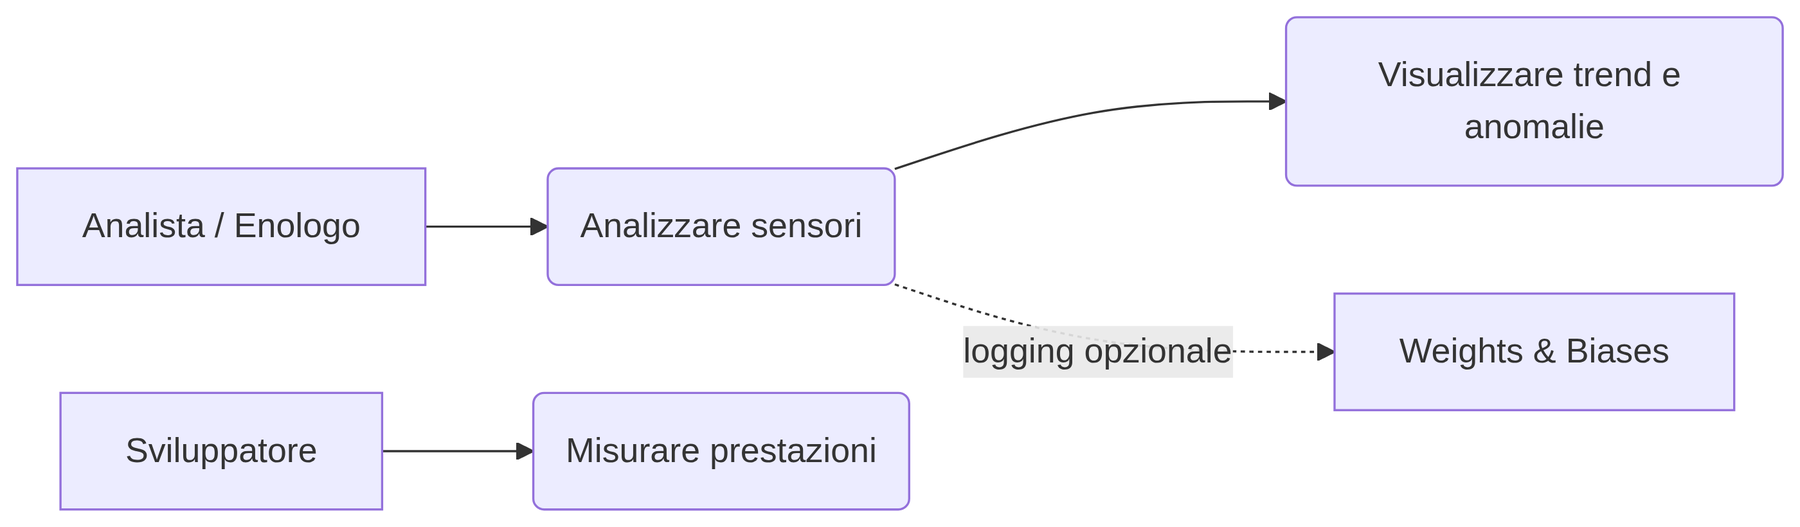
  <figcaption style="font-size:.88em;font-style:italic;margin-top:8px">Figura 3 — Casi d'uso: l'analista avvia l'analisi e consulta la dashboard, lo sviluppatore misura le prestazioni, Weights & Biases è un sistema esterno.</figcaption>
</figure><figure style="margin:20px 0;text-align:center">
  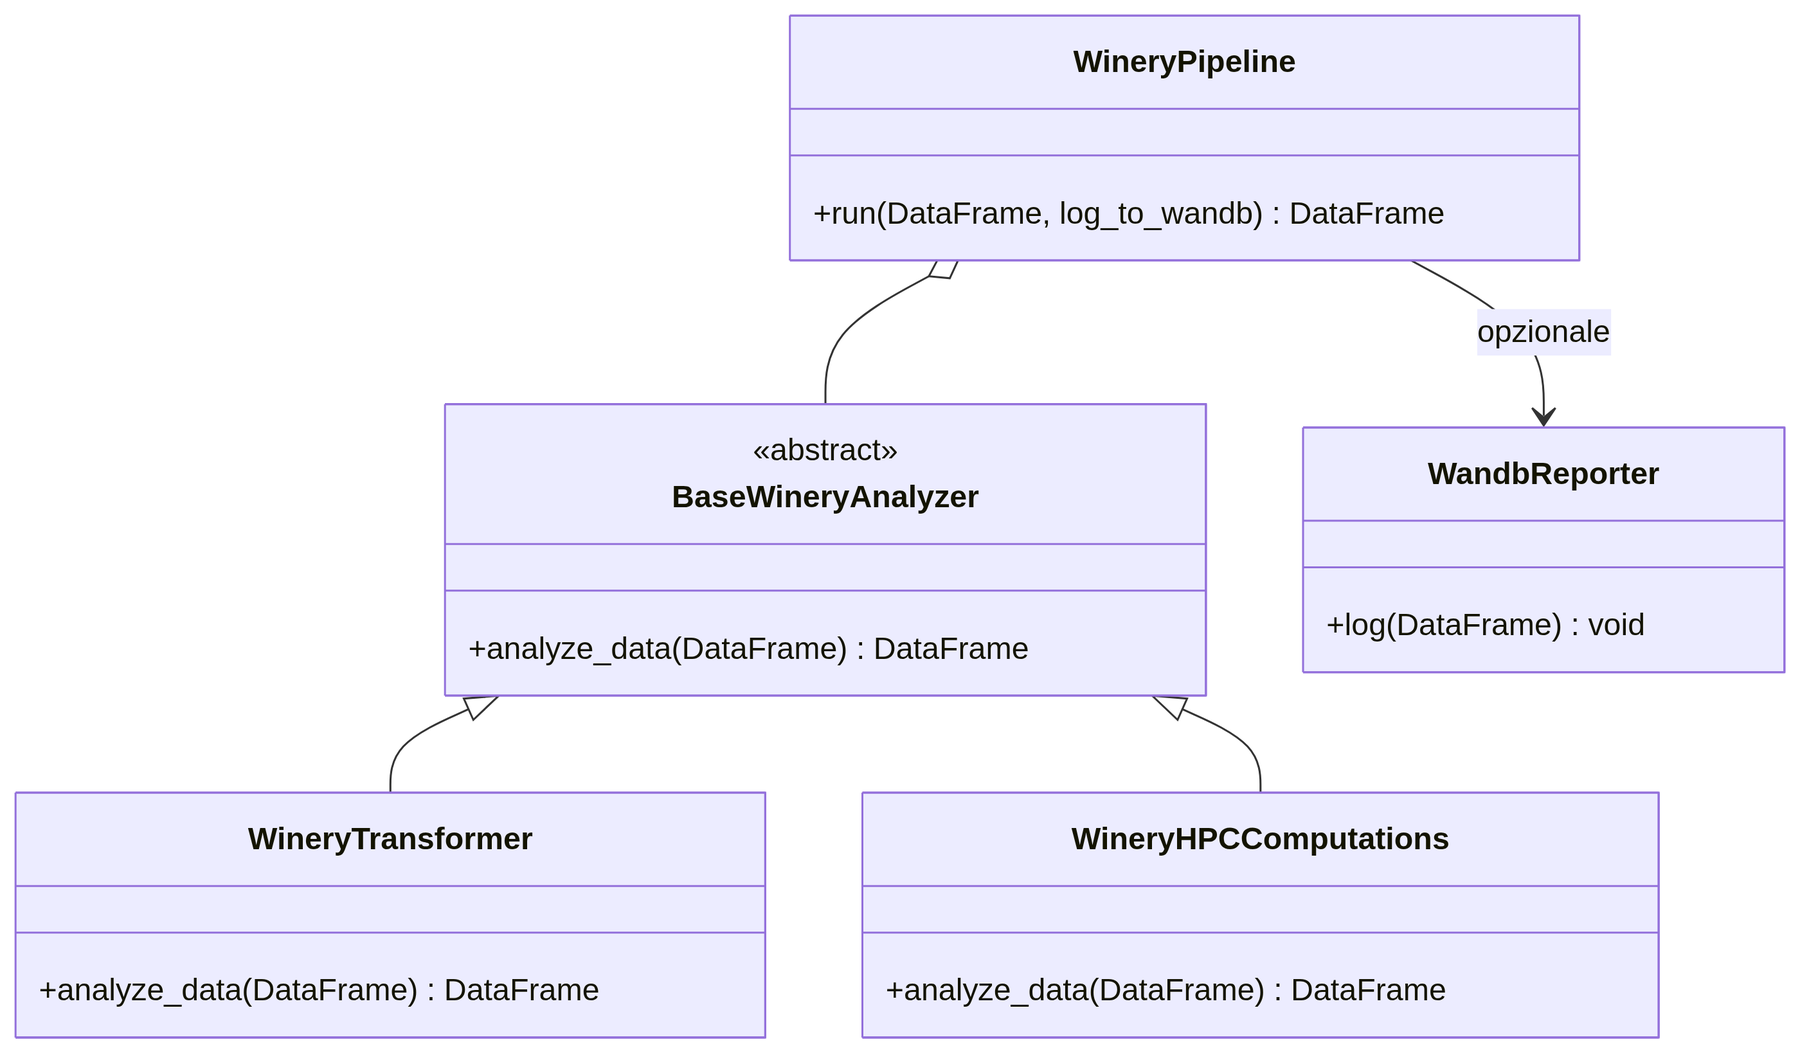
  <figcaption style="font-size:.88em;font-style:italic;margin-top:8px">Figura 4 — Diagramma delle classi: le due classi concrete estendono la classe astratta; la pipeline le contiene senza conoscerne i dettagli; il reporter W&B è opzionale.</figcaption>
</figure><figure style="margin:20px 0;text-align:center">
  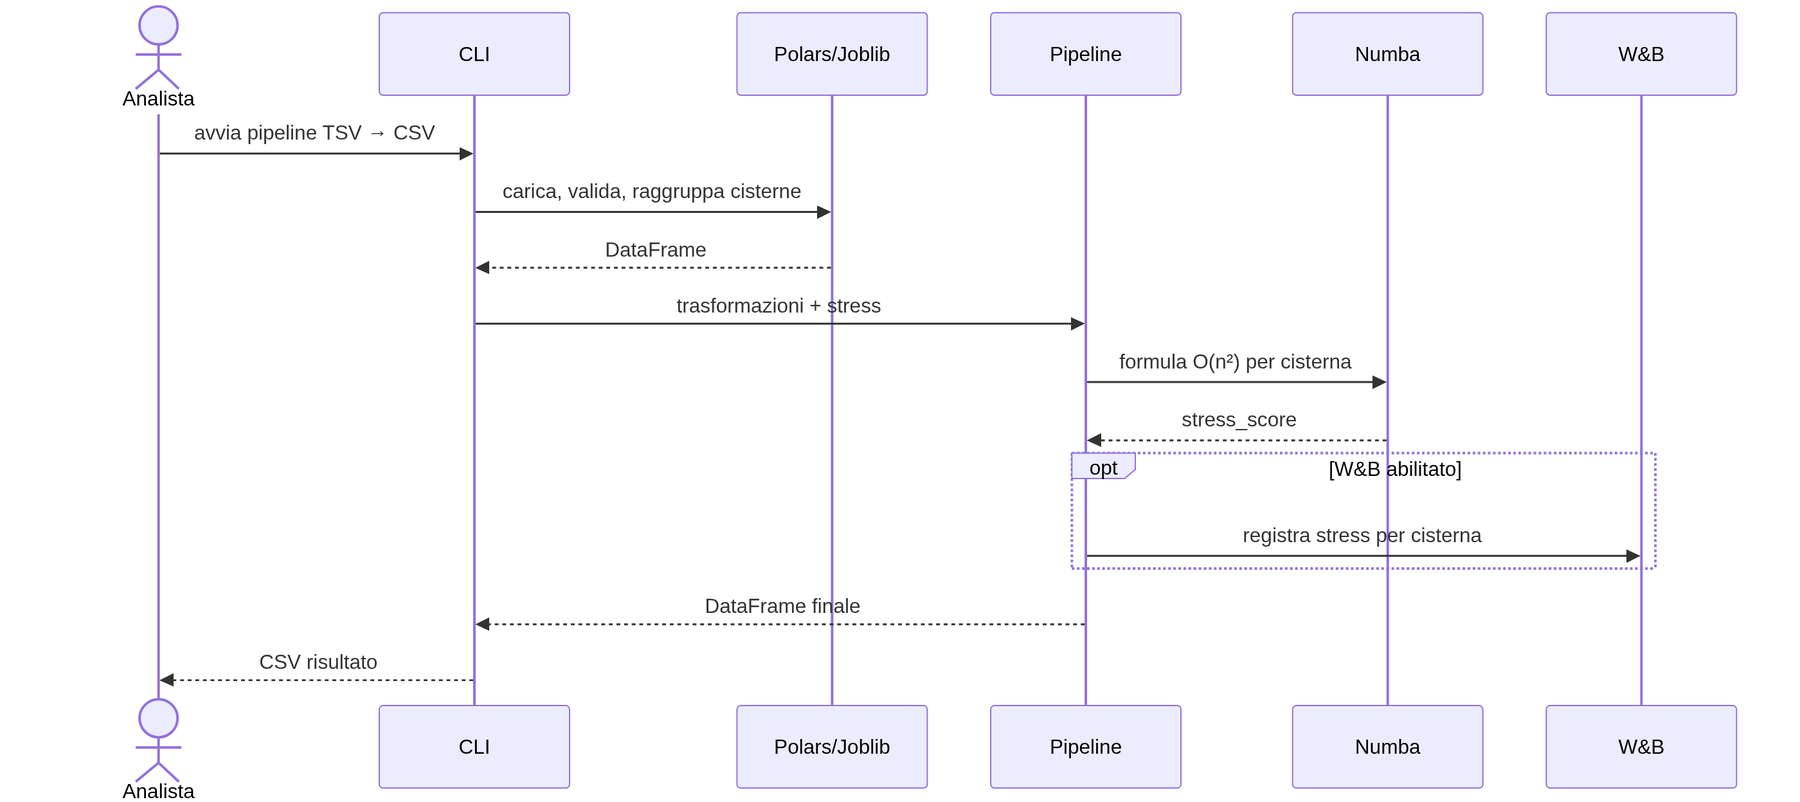
  <figcaption style="font-size:.88em;font-style:italic;margin-top:8px">Figura 5 — Diagramma di sequenza del caso d'uso principale: dalla riga di comando alla lettura dei file, alle trasformazioni, alla formula e al CSV.</figcaption>
</figure>

### I dati in ingresso

| File | Colonne | Note |
|---|---|---|
| Sensori (`sensors_*.tsv`) | `tank_id`, `time`, `pH`, `temp`, `quantity_liters` | una riga per rilevazione; i litri possono mancare |
| Cisterne (`tank_info_*.tsv`) | `tank_id`, `grape_variety`, `capacity_liters` | una riga per cisterna; più vitigni separati da virgola |

I dati sample della traccia contengono **100 rilevazioni di 9 cisterne** tra il 1° e l'11 gennaio 2025, in ordine sparso, e tre vitigni per cisterna. Prima di calcolare qualunque cosa, i file vengono controllati: se il file manca, mancano colonne, non ci sono rilevazioni o le informazioni sulle cisterne sono duplicate, la pipeline si ferma subito con un messaggio chiaro invece di produrre un risultato sbagliato.

**La cisterna 9** ha solo 8 rilevazioni — le possiamo mostrare tutte — e meno mosto di tutte le altre; vedremo che è anche la più "stressata".

In [ ]:
# ▶ dati sample e cisterna 9
from winery_adventures.io import load_sensor_data, load_tank_info

sensors = load_sensor_data("data/sensors_sample.tsv")
tank_info = load_tank_info("data/tank_info_sample.tsv")
print(
    f"Sensori: {sensors.height} rilevazioni di {sensors['tank_id'].n_unique()} cisterne"
)
display(sensors.head(5))
display(tank_info)

TANK = 9
example_info = tank_info.filter(pl.col("tank_id") == TANK)
example_readings = sensors.filter(pl.col("tank_id") == TANK).sort("time")
display(
    sensors.group_by("tank_id")
    .agg(
        pl.len().alias("rilevazioni"),
        pl.col("quantity_liters").mean().alias("litri medi"),
    )
    .sort("tank_id")
)
print(f"Le {example_readings.height} rilevazioni della cisterna {TANK}:")
display(example_readings)

Sensori: 100 rilevazioni di 9 cisterne


tank_id,time,pH,temp,quantity_liters
i64,datetime[μs],f64,f64,i64
7,2025-01-06 08:00:00,3.160,27.740,544
2,2025-01-02 12:00:00,3.100,27.080,818
5,2025-01-01 23:00:00,3.460,22.750,587
2,2025-01-09 09:00:00,3.830,25.710,570
4,2025-01-02 01:00:00,3.660,26.640,281


tank_id,grape_variety,capacity_liters
i64,str,i64
1,"""NebbioloClassico,Montepulciano…",1624
2,"""VerdicchioElegante,MalvasiaSap…",1699
3,"""PascaleSelezionato,BarberaGene…",1597
4,"""MontepulcianoElegante,BovaleDo…",1653
5,"""CorvinaRustico,NuragusAvvolgen…",1009
6,"""ArneisAmbrato,SangioveseRustic…",1294
7,"""VernacciaRustico,AglianicoStor…",1075
8,"""ViognierAmbrato,AglianicoSuper…",1601
9,"""CaricagiolaBarricato,GiroMorbi…",1434


tank_id,rilevazioni,litri medi
i64,u32,f64
1,9,625.556
2,16,609.188
3,13,596.769
4,11,588.727
5,10,569.200
6,11,607.364
7,12,662.583
8,10,615.100
9,8,464.750


Le 8 rilevazioni della cisterna 9:


tank_id,time,pH,temp,quantity_liters
i64,datetime[μs],f64,f64,i64
9,2025-01-01 23:00:00,3.310,22.300,688
9,2025-01-02 12:00:00,3.900,23.140,245
9,2025-01-03 08:00:00,3.530,25.640,416
9,2025-01-04 22:00:00,3.310,27.970,865
9,2025-01-06 08:00:00,3.200,26.300,444
9,2025-01-07 19:00:00,3.750,27.550,442
9,2025-01-07 21:00:00,3.980,25.220,228
9,2025-01-09 05:00:00,3.060,25.050,390


In [ ]:
# ▶ input errati: due file volutamente scorretti e un percorso inesistente,
# passati alle stesse funzioni di caricamento.
broken_dir = demo_dir / "input_errati"
broken_dir.mkdir(exist_ok=True)
(broken_dir / "senza_colonne.tsv").write_text(
    "tank_id\ttime\tpH\n1\t2025-01-01 00:00\t3.4\n", encoding="utf-8"
)
(broken_dir / "cisterne_duplicate.tsv").write_text(
    "tank_id\tgrape_variety\tcapacity_liters\n1\tCannonau\t1000\n1\tBovale\t1200\n",
    encoding="utf-8",
)
cases = [
    ("file inesistente", load_sensor_data, broken_dir / "non_esiste.tsv"),
    ("colonne mancanti", load_sensor_data, broken_dir / "senza_colonne.tsv"),
    ("cisterne duplicate", load_tank_info, broken_dir / "cisterne_duplicate.tsv"),
]
for label, loader, path in cases:
    try:
        loader(path)
    except (FileNotFoundError, ValueError) as error:
        print(f"{label:20} → {type(error).__name__}: {error}")
    else:
        raise AssertionError(f"Il caso '{label}' non ha sollevato alcun errore")

file inesistente     → FileNotFoundError: File dei sensori non trovato: /Users/alexandro/Desktop/Winery-Adventures-main/output/demo/input_errati/non_esiste.tsv
colonne mancanti     → ValueError: Colonne mancanti nei dati dei sensori: quantity_liters, temp
cisterne duplicate   → ValueError: Le informazioni delle cisterne non sono valide


### La pipeline al lavoro

Il comando `winery-adventures` legge i sensori, prepara le cisterne in parallelo (Joblib), aggiunge gli indicatori (Polars), calcola lo stress (Numba) e scrive il CSV. Lo eseguiamo sui dati sample senza W&B e con un solo worker, come fanno i test; le righe `INFO` sono il diario della pipeline.

| Colonna del CSV | Cosa contiene |
|---|---|
| `tank_id`, `time`, `pH`, `temp`, `quantity_liters` | le misure originali, ordinate per tempo dentro ogni cisterna |
| `avg_pH_per_tank`, `tank_num_readings` | pH medio e numero di rilevazioni della cisterna |
| `grape_variety`, `grape_variety_num_readings` | il vitigno e quante rilevazioni gli sono associate |
| `temperature_deviation_scaled` | distanza dai 26 °C standard, rapportata ai litri (senza litri: `temperature_deviation`, non rapportata) |
| `stress_score` | lo stress di fermentazione della cisterna |

**Perché 100 rilevazioni diventano 300 righe.** Ogni rilevazione viene abbinata a ciascuno dei tre vitigni della sua cisterna (una join con le informazioni e l'*explode* della lista): è così che si contano le rilevazioni per vitigno, come chiede la traccia. Gli indicatori per cisterna — pH medio, numero di rilevazioni, stress — sono ripetuti su ogni riga della cisterna: si leggono una volta per cisterna, non si sommano.

In [ ]:
# ▶ esecuzione della pipeline
from winery_adventures.main import run_full_pipeline

results_csv = demo_dir / "results.csv"
started = perf_counter()
returned = run_full_pipeline(
    "data/sensors_sample.tsv",
    "data/tank_info_sample.tsv",
    results_csv,
    log_to_wandb=False,
    n_jobs=1,
)
elapsed = perf_counter() - started
results = pl.read_csv(results_csv, try_parse_dates=True)
print(f"\nTempo complessivo: {elapsed:.3f} s → {results_csv.relative_to(repo_root)}")
print(f"Risultato: {results.height} righe × {results.width} colonne")
print(f"CSV e DataFrame restituito coincidono: {results.height == returned.height}")
display(results.head(5))
print("Indicatori per cisterna, una riga per tank_id:")
display(
    results.select("tank_id", "tank_num_readings", "avg_pH_per_tank", "stress_score")
    .unique()
    .sort("tank_id")
)

INFO winery_adventures.pipeline: Esecuzione WineryTransformer


INFO winery_adventures.pipeline: Esecuzione WineryHPCComputations



Tempo complessivo: 0.093 s → output/demo/results.csv
Risultato: 300 righe × 11 colonne
CSV e DataFrame restituito coincidono: True


tank_id,time,pH,temp,quantity_liters,avg_pH_per_tank,tank_num_readings,grape_variety,grape_variety_num_readings,temperature_deviation_scaled,stress_score
i64,datetime[μs],f64,f64,f64,f64,i64,str,i64,f64,f64
7,2025-01-01 06:00:00,3.830,24.340,988.000,3.609,12,"""VernacciaRustico""",12,1.680,6.757
7,2025-01-01 06:00:00,3.830,24.340,988.000,3.609,12,"""AglianicoStorico""",12,1.680,6.757
7,2025-01-01 06:00:00,3.830,24.340,988.000,3.609,12,"""PrimitivoClassico""",12,1.680,6.757
7,2025-01-01 16:00:00,3.930,25.230,936.000,3.609,12,"""VernacciaRustico""",12,0.823,6.757
7,2025-01-01 16:00:00,3.930,25.230,936.000,3.609,12,"""AglianicoStorico""",12,0.823,6.757


Indicatori per cisterna, una riga per tank_id:


tank_id,tank_num_readings,avg_pH_per_tank,stress_score
i64,i64,f64,f64
1,9,3.433,7.009
2,16,3.453,7.435
3,13,3.392,6.505
4,11,3.485,7.621
5,10,3.664,8.443
6,11,3.531,6.950
7,12,3.609,6.757
8,10,3.533,10.439
9,8,3.505,11.030


In [ ]:
# ▶ cisterna 9 dopo la pipeline: 8 rilevazioni × 3 vitigni = 24 righe.
example_rows = results.filter(pl.col("tank_id") == TANK).sort("time", "grape_variety")
varieties = example_info["grape_variety"][0].split(",")
assert example_rows.height == example_readings.height * len(varieties)
assert example_rows["stress_score"].n_unique() == 1
stress_9 = example_rows["stress_score"][0]
print(
    f"Cisterna {TANK}: {example_readings.height} rilevazioni × {len(varieties)} "
    f"vitigni = {example_rows.height} righe, stress {stress_9:.2f}"
)
print("La prima rilevazione, ripetuta per ognuno dei suoi vitigni:")
display(
    example_rows.filter(pl.col("time") == example_rows["time"].min()).drop(
        "temp", "quantity_liters", "temperature_deviation_scaled"
    )
)

Cisterna 9: 8 rilevazioni × 3 vitigni = 24 righe, stress 11.03
La prima rilevazione, ripetuta per ognuno dei suoi vitigni:


tank_id,time,pH,avg_pH_per_tank,tank_num_readings,grape_variety,grape_variety_num_readings,stress_score
i64,datetime[μs],f64,f64,i64,str,i64,f64
9,2025-01-01 23:00:00,3.310,3.505,8,"""CaricagiolaBarricato""",8,11.030
9,2025-01-01 23:00:00,3.310,3.505,8,"""FianoSublime""",8,11.030
9,2025-01-01 23:00:00,3.310,3.505,8,"""GiroMorbido""",8,11.030


### La formula di stress

Per ogni cisterna, la formula confronta ogni rilevazione con tutte le altre: quanto cambiano pH e temperatura (la temperatura pesa il doppio) e quanto poco mosto c'è (500 litri diviso la quantità: meno mosto, più sensibilità). Più le letture sono diverse tra loro e più la cisterna è vuota, più lo stress cresce; le rilevazioni senza pH, temperatura o litri restano nel risultato ma non entrano nel calcolo. Confrontare tutte le coppie significa $n^2$ operazioni per cisterna: per questo la funzione è compilata da Numba in codice macchina — stessa formula, centinaia di volte più veloce, come vedremo nella sezione sulle prestazioni. Sull'esempio del tutor (due rilevazioni: pH 3,4 e 3,6, 25 e 26 °C, 500 litri) il risultato atteso è **2,2**.

In [ ]:
# ▶ formula: esempio del tutor
from winery_adventures.computations import pairwise_stress_function

pH, temp, liters = (
    np.array([3.4, 3.6]),
    np.array([25.0, 26.0]),
    np.array([500.0, 500.0]),
)
print(f"Esempio del tutor → stress {pairwise_stress_function(pH, temp, liters)}")
print(f"Cisterna 9 (dal CSV) → stress {stress_9:.4f}")

Esempio del tutor → stress 2.2
Cisterna 9 (dal CSV) → stress 11.0301


### Weights & Biases è facoltativo

Se il logging è attivo, la pipeline apre un run su Weights & Biases e registra lo stress di ogni cisterna. Se W&B non è raggiungibile — nessun account, nessuna rete — il reporter intercetta l'errore (`try/except` in `reporting.py`), scrive un avviso nel log e la pipeline va avanti: il CSV arriva comunque. Qui il run è in modalità *offline*, salvato in locale senza autenticazione.

In [ ]:
# ▶ W&B offline
started = perf_counter()
logged = run_full_pipeline(
    "data/sensors_sample.tsv",
    "data/tank_info_sample.tsv",
    demo_dir / "results_wandb.csv",
    project_name="Winery-Adventures-demo",
    log_to_wandb=True,
    n_jobs=1,
)
wandb_seconds = perf_counter() - started
runs = sorted((demo_dir / "wandb").glob("offline-run-*"))
print(f"Run W&B offline completato in {wandb_seconds:.2f} s → {runs[-1].name}")
print(f"Righe prodotte con stress_score: {logged.height}")

INFO winery_adventures.pipeline: Esecuzione WineryTransformer


INFO winery_adventures.pipeline: Esecuzione WineryHPCComputations


Run W&B offline completato in 0.54 s → offline-run-20260915_231417-nfah7p0i
Righe prodotte con stress_score: 300


<a id="parte4"></a>
<div style="background:#f3e9e4;color:#2b2523;border-left:6px solid #7b2d3b;padding:12px 18px;margin:30px 0 14px;border-radius:0 6px 6px 0">
  <div style="font-size:1.3em;font-weight:600;margin:0 0 6px">Prestazioni e dashboard</div>
  <ul style="margin:0;padding-left:20px;font-size:.92em"><li>Quanto guadagna Numba sulla formula, misurato dal vivo, e come cresce il tempo con n.</li><li>La pipeline su 100 000 rilevazioni, il ruolo di Joblib e il report archiviato nel repository.</li><li>La dashboard: quali cisterne risultano anomale e perché.</li></ul>
</div>

### Python contro Numba

Lo script `scripts/benchmark.py` misura tre cose: la formula scritta in Python puro, la stessa formula compilata da Numba e la pipeline completa su 100 000 rilevazioni di 100 cisterne generate in memoria; controlla che Python e Numba diano lo stesso risultato e salva il report in `docs/performance/performance_report.md`. Qui ripetiamo le misure sulla macchina della presentazione, importando le funzioni dello script: 300 rilevazioni, 90 000 coppie, una sola esecuzione per variante.

In [ ]:
# ▶ Python contro Numba
sys.path.insert(0, str(repo_root / "scripts"))
from benchmark import python_stress, sample_data  # noqa: E402

N_READINGS = 300
formula_data = sample_data(N_READINGS, 1, 42)
b_pH = formula_data["pH"].to_numpy()
b_temp = formula_data["temp"].to_numpy()
b_quantity = formula_data["quantity_liters"].cast(pl.Float64).to_numpy()

started = perf_counter()
python_value = python_stress(b_pH, b_temp, b_quantity)
python_ms = (perf_counter() - started) * 1000

pairwise_stress_function(
    b_pH, b_temp, b_quantity
)  # riscaldamento: eventuale compilazione
started = perf_counter()
numba_value = pairwise_stress_function(b_pH, b_temp, b_quantity)
numba_ms = (perf_counter() - started) * 1000

assert np.isclose(python_value, numba_value)
print(f"Carico: {N_READINGS} rilevazioni, {N_READINGS**2:,} coppie, stesso risultato")
print(f"Python puro:    {python_ms:9.3f} ms")
print(f"Numba:          {numba_ms:9.3f} ms")
print(f"Accelerazione:  {python_ms / numba_ms:,.0f}×")

Carico: 300 rilevazioni, 90,000 coppie, stesso risultato
Python puro:       55.673 ms
Numba:              0.119 ms
Accelerazione:  467×


### Come cresce il tempo con il numero di rilevazioni

Dal confronto di tutte le coppie, si osserva come Numba non cambia la forma della curva, la abbassa di centinaia di volte. 

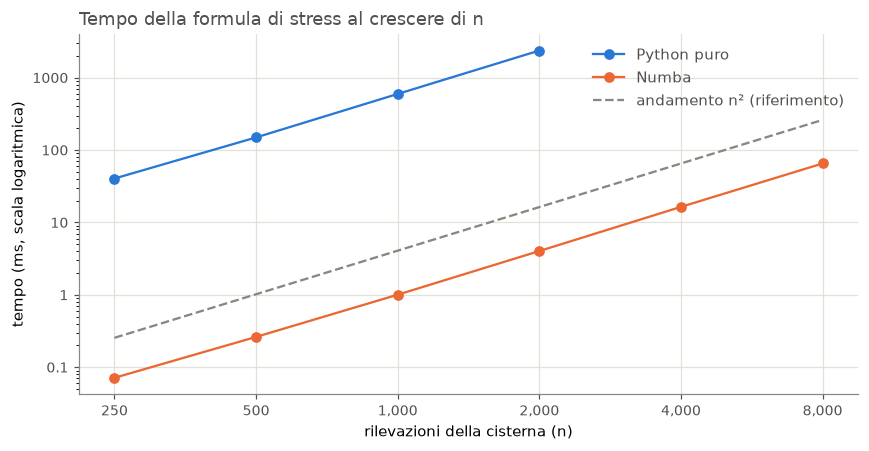

In [ ]:
# ▶ grafico O(n²)
sizes = [250, 500, 1000, 2000, 4000, 8000]
rows = []
for size in sizes:
    frame = sample_data(size, 1, 7)
    s_pH = frame["pH"].to_numpy()
    s_temp = frame["temp"].to_numpy()
    s_quantity = frame["quantity_liters"].cast(pl.Float64).to_numpy()
    started = perf_counter()
    pairwise_stress_function(s_pH, s_temp, s_quantity)
    numba_ms = (perf_counter() - started) * 1000
    python_ms = None
    if size <= 2000:
        started = perf_counter()
        python_stress(s_pH, s_temp, s_quantity)
        python_ms = (perf_counter() - started) * 1000
    rows.append({"n": size, "Python (ms)": python_ms, "Numba (ms)": numba_ms})
scaling = pl.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.2))
python_points = scaling.filter(pl.col("Python (ms)").is_not_null())
ax.plot(
    python_points["n"],
    python_points["Python (ms)"],
    "o-",
    color=BLUE,
    label="Python puro",
)
ax.plot(scaling["n"], scaling["Numba (ms)"], "o-", color=ORANGE, label="Numba")
reference_n = np.array([sizes[0], sizes[-1]])
reference = 4 * scaling["Numba (ms)"][-1] * (reference_n / sizes[-1]) ** 2
ax.plot(reference_n, reference, "--", color=MUTED, label="andamento n² (riferimento)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(sizes, [f"{s:,}" for s in sizes])
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:g}"))
ax.set_xlabel("rilevazioni della cisterna (n)")
ax.set_ylabel("tempo (ms, scala logaritmica)")
ax.set_title("Tempo della formula di stress al crescere di n", color=INK, loc="left")
ax.legend(frameon=False, labelcolor=INK)
style_axes(ax)
plt.tight_layout()
plt.show()

### Pipeline completa, Joblib e report archiviato

Facendo girare tutta la pipeline su un dataset grande: 100 000 letture di 100 cisterne, ci mette talmente poco tempo che non diventa utile usare joblib per parallelizzare la preparazione delle cisterne non porta vantaggi.

Infatti Joblib fa lavorare più processi in parallelo, ma avviare quei processi ha un costo di tempo. Per questo nei test e nel benchmark usiamo un solo processo (`n_jobs=1`), così la misura è sempre uguale.

Alla fine mostriamo il report salvato nel repository: tempi e anche quanta memoria usa la pipeline.

In [ ]:
# ▶ pipeline su 100 000 righe, Joblib e report
from winery_adventures import WineryHPCComputations, WineryPipeline, WineryTransformer
from winery_adventures.io import prepare_sensor_data

big = sample_data(100_000, 100, 42)
started = perf_counter()
big_prepared = prepare_sensor_data(big, n_jobs=1)
WineryPipeline([WineryTransformer(), WineryHPCComputations()]).run(big_prepared)
pipeline_seconds = perf_counter() - started
n_big_tanks = big["tank_id"].n_unique()
print(
    f"Pipeline: {big.height:,} righe, {n_big_tanks} cisterne → {pipeline_seconds:.3f} s"
)

joblib_rows = []
for label, n_jobs in [
    ("n_jobs=1 (un solo worker)", 1),
    ("n_jobs=-1, prima misura", -1),
    ("n_jobs=-1, misura successiva", -1),
]:
    started = perf_counter()
    prepare_sensor_data(big, n_jobs=n_jobs)
    joblib_rows.append(
        {"preparazione delle cisterne": label, "s": perf_counter() - started}
    )
print(f"\nProcessori disponibili: {os.cpu_count()}")
display(pl.DataFrame(joblib_rows))

report = Path("docs/performance/performance_report.md").read_text(encoding="utf-8")
display(Markdown(report))

INFO winery_adventures.pipeline: Esecuzione WineryTransformer


INFO winery_adventures.pipeline: Esecuzione WineryHPCComputations


Pipeline: 100,000 righe, 100 cisterne → 0.184 s



Processori disponibili: 8


preparazione delle cisterne,s
str,f64
"""n_jobs=1 (un solo worker)""",0.016
"""n_jobs=-1, prima misura""",1.836
"""n_jobs=-1, misura successiva""",0.041


# Report delle prestazioni

Generato con `python scripts/benchmark.py --rows 100000 --tanks 100`.

| Misura | Dimensione | Tempo (s) |
|---|---:|---:|
| Formula Python | 300 rilevazioni | 0.043907 |
| Formula Numba (JIT caldo) | 300 rilevazioni | 0.000068 |
| Pipeline Polars + Joblib | 100000 righe, 100 cisterne | 0.127866 |

Picco di memoria Python tracciato durante la pipeline: **3.87 MiB**.

La formula di stress segue il requisito `O(n²)` per cisterna. Numba elimina il
costo dell'interprete nel doppio ciclo; Polars mantiene le trasformazioni
colonnari e Joblib prepara i gruppi per cisterna. Il benchmark usa un worker
per una misura ripetibile; la CLI usa tutti i processori per default.

La memoria è misurata con `tracemalloc`: rappresenta le allocazioni Python
tracciabili durante la pipeline, non l'intero RSS dei componenti nativi.


### La dashboard

Il comando `winery-dashboard` legge il CSV della pipeline — la sua unica sorgente — e scrive una pagina HTML autosufficiente, senza librerie esterne: si apre con un doppio clic e si può allegare a una mail. Contiene la **tabella** delle cisterne con pH medio, temperatura media, stress e anomalie, un **confronto delle temperature** in cui ogni cisterna si accende e si spegne con una casella, e nove **grafici separati** con la stessa scala, perché nove linee sovrapposte sarebbero illeggibili.

Le regole di anomalia sono scritte nella pagina stessa: pH medio fuori da 3,0–4,0, temperatura media fuori da 22–28 °C, stress sopra la **media più una deviazione standard** delle nove cisterne (una soglia relativa: segnala chi si discosta dalle altre). Ricalcoliamo la soglia con la stessa logica della dashboard: la cisterna 9 supera la soglia perché ha poche rilevazioni, molto diverse tra loro e con poco mosto. Poi generiamo la dashboard vera e la mostriamo qui dentro.

In [ ]:
# ▶ soglia delle anomalie
import statistics

from winery_adventures.dashboard import _anomalies, create_dashboard

unique_readings = results.unique(subset=["tank_id", "time"], maintain_order=True)
dashboard_summary = unique_readings.group_by("tank_id", maintain_order=True).agg(
    pl.col("pH").mean().alias("pH medio"),
    pl.col("temp").mean().alias("temperatura media"),
    pl.col("stress_score").first().alias("stress"),
)
stresses = dashboard_summary["stress"].to_list()
stress_limit = statistics.mean(stresses) + statistics.stdev(stresses)


def anomalies_of(row: dict) -> str:
    return _anomalies(
        row["pH medio"], row["temperatura media"], row["stress"], stress_limit
    )


dashboard_summary = dashboard_summary.with_columns(
    pl.struct("pH medio", "temperatura media", "stress")
    .map_elements(anomalies_of, return_dtype=pl.String)
    .alias("anomalie")
).sort("tank_id")
print(
    f"Soglia di stress: media {statistics.mean(stresses):.2f} + "
    f"deviazione standard {statistics.stdev(stresses):.2f} = {stress_limit:.2f}"
)
display(dashboard_summary)

Soglia di stress: media 8.02 + deviazione standard 1.65 = 9.67


tank_id,pH medio,temperatura media,stress,anomalie
i64,f64,f64,f64,str
1,3.433,25.569,7.009,"""nessuna"""
2,3.453,25.586,7.435,"""nessuna"""
3,3.392,24.820,6.505,"""nessuna"""
4,3.485,25.537,7.621,"""nessuna"""
5,3.664,24.607,8.443,"""nessuna"""
6,3.559,24.594,6.950,"""nessuna"""
7,3.609,25.448,6.757,"""nessuna"""
8,3.533,25.518,10.439,"""stress sopra media + deviazion…"
9,3.505,25.396,11.030,"""stress sopra media + deviazion…"


In [ ]:
# ▶ dashboard
import html
import warnings

dashboard_html = create_dashboard(results_csv, demo_dir / "dashboard.html")
page = dashboard_html.read_text(encoding="utf-8")
print(f"Dashboard scritta: {dashboard_html.relative_to(repo_root)}")
frame_style = "width:100%;height:900px;border:1px solid #d8d0cb;border-radius:4px;"
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)  # IPython suggerisce IFrame(src=...)
    display(
        HTML(f'<iframe srcdoc="{html.escape(page)}" style="{frame_style}"></iframe>')
    )

Dashboard scritta: output/demo/dashboard.html
